In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk


# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset locations
TRAIN_PATH = PROJECT_ROOT / "data" / "splits" / "train"
VAL_PATH = PROJECT_ROOT / "data" / "splits" / "validation"
TEST_PATH = PROJECT_ROOT / "data" / "splits" / "test"

print("Project root:", PROJECT_ROOT)
print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)

Project root: c:\Text-to-SQL
Train path: c:\Text-to-SQL\data\splits\train
Validation path: c:\Text-to-SQL\data\splits\validation
Test path: c:\Text-to-SQL\data\splits\test


In [3]:
train_dataset = load_from_disk(str(TRAIN_PATH))
val_dataset = load_from_disk(str(VAL_PATH))
test_dataset = load_from_disk(str(TEST_PATH))

print(f"Train      : {len(train_dataset):,}")
print(f"Validation : {len(val_dataset):,}")
print(f"Test       : {len(test_dataset):,}")

Train      : 70,719
Validation : 3,929
Test       : 3,929


In [4]:
print(train_dataset)
print("\nColumns:")
print(train_dataset.column_names)
train_dataset[0]

Dataset({
    features: ['answer', 'question', 'context'],
    num_rows: 70719
})

Columns:
['answer', 'question', 'context']


{'answer': 'SELECT insurgents FROM table_name_75 WHERE civilians = "49"',
 'question': 'Name the insurgents for civilians being 49',
 'context': 'CREATE TABLE table_name_75 (insurgents VARCHAR, civilians VARCHAR)'}

In [5]:
df_sample = train_dataset.select(range(min(1000, len(train_dataset)))).to_pandas()

df_sample.head()

,answer,question,context
0,SELECT insurgents FROM table_name_75 WHERE civ...,Name the insurgents for civilians being 49,CREATE TABLE table_name_75 (insurgents VARCHAR...
1,SELECT affiliation FROM table_20887670_1 WHERE...,what is the affiliation of the hilltoppers mas...,CREATE TABLE table_20887670_1 (affiliation VAR...
2,SELECT became_consort FROM table_name_86 WHERE...,On what date did the woman married to Louis II...,CREATE TABLE table_name_86 (became_consort VAR...
3,SELECT original_air_date FROM table_14035132_3...,When did the episode with season number 10b ai...,CREATE TABLE table_14035132_3 (original_air_da...
4,SELECT tournament FROM table_name_85 WHERE par...,In what Tournament was Barbara Jordan a Partne...,CREATE TABLE table_name_85 (tournament VARCHAR...


In [6]:
df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   answer    1000 non-null   str  
 1   question  1000 non-null   str  
 2   context   1000 non-null   str  
dtypes: str(3)
memory usage: 226.6 KB


In [7]:
# Basic dataset statistics

total_examples = (
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
)

print(f"Total examples: {total_examples:,}")
print(f"Train:          {len(train_dataset):,} ({len(train_dataset)/total_examples:.2%})")
print(f"Validation:     {len(val_dataset):,} ({len(val_dataset)/total_examples:.2%})")
print(f"Test:           {len(test_dataset):,} ({len(test_dataset)/total_examples:.2%})")

Total examples: 78,577
Train:          70,719 (90.00%)
Validation:     3,929 (5.00%)
Test:           3,929 (5.00%)


In [8]:
# Convert complete datasets to pandas for analysis

train_df = train_dataset.to_pandas()
val_df = val_dataset.to_pandas()
test_df = test_dataset.to_pandas()

for df in [train_df, val_df, test_df]:
    df["question_chars"] = df["question"].str.len()
    df["sql_chars"] = df["answer"].str.len()
    df["schema_chars"] = df["context"].str.len()

train_df.head()

,answer,question,context,question_chars,sql_chars,schema_chars
0,SELECT insurgents FROM table_name_75 WHERE civ...,Name the insurgents for civilians being 49,CREATE TABLE table_name_75 (insurgents VARCHAR...,42,59,66
1,SELECT affiliation FROM table_20887670_1 WHERE...,what is the affiliation of the hilltoppers mas...,CREATE TABLE table_20887670_1 (affiliation VAR...,50,69,67
2,SELECT became_consort FROM table_name_86 WHERE...,On what date did the woman married to Louis II...,CREATE TABLE table_name_86 (became_consort VAR...,62,66,67
3,SELECT original_air_date FROM table_14035132_3...,When did the episode with season number 10b ai...,CREATE TABLE table_14035132_3 (original_air_da...,68,73,79
4,SELECT tournament FROM table_name_85 WHERE par...,In what Tournament was Barbara Jordan a Partne...,CREATE TABLE table_name_85 (tournament VARCHAR...,78,97,79


In [9]:
# Length statistics

length_stats = train_df[
    ["question_chars", "sql_chars", "schema_chars"]
].describe()

length_stats

,question_chars,sql_chars,schema_chars
count,70719.000000,70719.000000,70719.000000
mean,60.654237,76.263564,71.605707
std,23.210965,24.598193,19.639254
min,12.000000,20.000000,27.000000
25%,43.000000,62.000000,60.000000
50%,57.000000,71.000000,68.000000
75%,73.000000,85.000000,78.000000
max,244.000000,557.000000,489.000000


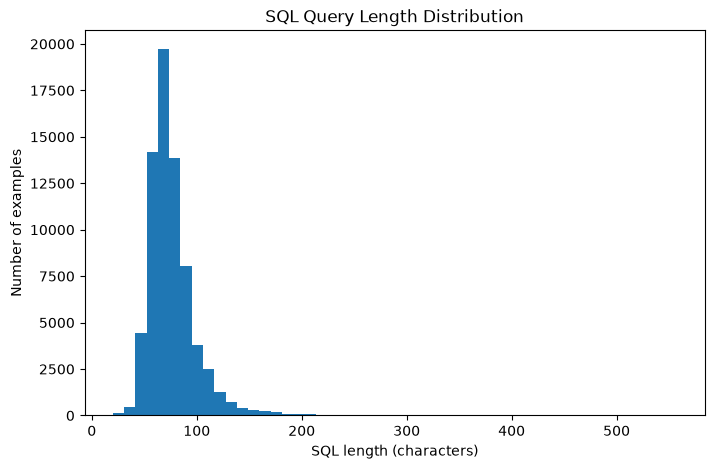

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_df["sql_chars"],
    bins=50
)

plt.xlabel("SQL length (characters)")
plt.ylabel("Number of examples")
plt.title("SQL Query Length Distribution")

plt.show()

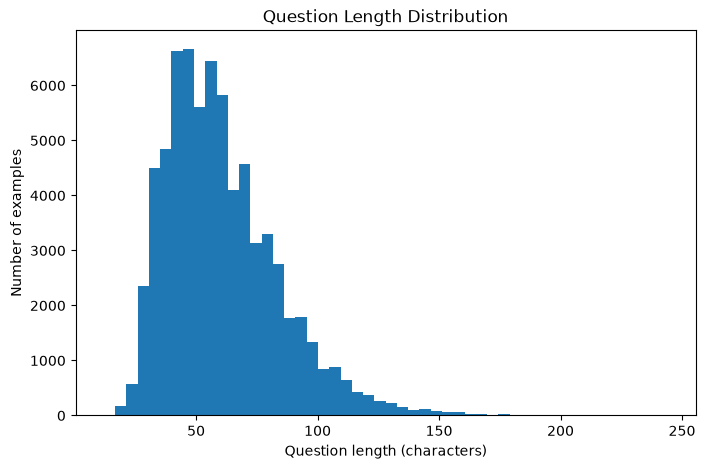

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    train_df["question_chars"],
    bins=50
)

plt.xlabel("Question length (characters)")
plt.ylabel("Number of examples")
plt.title("Question Length Distribution")

plt.show()

In [12]:
import re


def contains_sql_keyword(sql, keyword):
    return bool(
        re.search(
            rf"\b{keyword}\b",
            sql,
            flags=re.IGNORECASE
        )
    )


sql_operations = {
    "SELECT": "SELECT",
    "WHERE": "WHERE",
    "GROUP BY": "GROUP BY",
    "ORDER BY": "ORDER BY",
    "HAVING": "HAVING",
    "JOIN": "JOIN",
    "DISTINCT": "DISTINCT",
    "LIMIT": "LIMIT",
    "COUNT": "COUNT",
    "AVG": "AVG",
    "SUM": "SUM",
    "MIN": "MIN",
    "MAX": "MAX",
    "LIKE": "LIKE",
    "IN": "IN",
    "BETWEEN": "BETWEEN",
}

In [13]:
operation_counts = {}

for name, keyword in sql_operations.items():
    operation_counts[name] = train_df["answer"].apply(
        lambda sql: contains_sql_keyword(sql, keyword)
    ).sum()

operation_counts

{'SELECT': np.int64(70719),
 'WHERE': np.int64(68084),
 'GROUP BY': np.int64(1043),
 'ORDER BY': np.int64(970),
 'HAVING': np.int64(263),
 'JOIN': np.int64(1623),
 'DISTINCT': np.int64(407),
 'LIMIT': np.int64(657),
 'COUNT': np.int64(7489),
 'AVG': np.int64(2896),
 'SUM': np.int64(2536),
 'MIN': np.int64(3898),
 'MAX': np.int64(3994),
 'LIKE': np.int64(85),
 'IN': np.int64(335),
 'BETWEEN': np.int64(44)}

In [14]:
operation_df = (
    pd.DataFrame(
        list(operation_counts.items()),
        columns=["operation", "count"]
    )
    .sort_values("count", ascending=False)
)

operation_df["percentage"] = (
    operation_df["count"] / len(train_df) * 100
)

operation_df

,operation,count,percentage
0,SELECT,70719,100.000000
1,WHERE,68084,96.273986
8,COUNT,7489,10.589799
12,MAX,3994,5.647704
11,MIN,3898,5.511956
9,AVG,2896,4.095081
10,SUM,2536,3.586024
5,JOIN,1623,2.294999
2,GROUP BY,1043,1.474851
3,ORDER BY,970,1.371626


In [15]:
# Exact duplicate counts

print("Train duplicates:", train_df.duplicated().sum())
print("Validation duplicates:", val_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Validation duplicates: 0
Test duplicates: 0
